In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

hdp_df = pd.read_csv("hdp.csv")
ga_df = pd.read_csv("ga.csv")

merged_df = hdp_df.merge(
    ga_df,
    on=["dataset", "n", "m", "instance"],
    suffixes=("_hdp", "_ga")
)

merged_df["profit_diff_percent"] = (
    (merged_df["profit_hdp"] - merged_df["profit_ga"])
    / merged_df["profit_ga"] * 100
)

merged_df["time_ratio"] = (
    merged_df["time_sec_hdp"] / merged_df["time_sec_ga"]
)

compare_df = merged_df[[
    "dataset", "n", "m", "instance",
    "profit_hdp", "profit_ga", "profit_diff_percent",
    "time_sec_hdp", "time_sec_ga", "time_ratio",
    "avg_usage_hdp", "avg_usage_ga"
]].copy()

compare_df = compare_df.rename(columns={
    "dataset": "Bộ dữ liệu",
    "n": "n",
    "m": "m",
    "instance": "Instance",
    "profit_hdp": "HDP Profit",
    "profit_ga": "GA Profit",
    "profit_diff_percent": "Chênh lệch Profit (%)",
    "time_sec_hdp": "HDP Time (s)",
    "time_sec_ga": "GA Time (s)",
    "time_ratio": "HDP/GA Time",
    "avg_usage_hdp": "HDP Usage TB",
    "avg_usage_ga": "GA Usage TB"
})

compare_df

,Bộ dữ liệu,n,m,Instance,HDP Profit,GA Profit,Chênh lệch Profit (%),HDP Time (s),GA Time (s),HDP/GA Time,HDP Usage TB,GA Usage TB
0,100-5,100,5,1,24304.0,24329,-0.102758,10.830,17.307987,0.625723,0.988,0.995476
1,100-5,100,5,2,24225.0,24274,-0.201862,9.013,32.355146,0.278565,0.988,0.988115
2,500-5,500,5,1,119963.0,119076,0.744902,497.763,135.006041,3.686968,0.999,0.997939
3,500-5,500,5,2,117685.0,116467,1.045790,429.302,85.198700,5.038833,0.997,0.998377
4,250-10,250,10,1,58896.0,58434,0.790636,155.325,54.863697,2.831107,0.990,0.988132
5,250-10,250,10,2,58480.0,58390,0.154136,218.095,52.829247,4.128300,0.990,0.991507
6,100-30,100,30,1,21686.0,21840,-0.705128,615.527,26.220258,23.475246,0.925,0.947597
7,100-30,100,30,2,21548.0,21576,-0.129774,620.731,26.138968,23.747342,0.928,0.934732
8,500-30,500,30,1,114655.0,114169,0.425685,603.493,121.621896,4.962042,0.982,0.986386


In [8]:
report_table = merged_df[[
    "dataset", "n", "m", "instance",
    "profit_hdp", "profit_ga",
    "profit_diff_percent",
    "time_sec_hdp", "time_sec_ga",
    "time_ratio",
    "avg_usage_hdp", "avg_usage_ga"
]].copy()

report_table["label"] = (
    report_table["dataset"] 
    + "-i" 
    + report_table["instance"].astype(str)
)

report_table["time_min_hdp"] = report_table["time_sec_hdp"] / 60
report_table["time_min_ga"] = report_table["time_sec_ga"] / 60

report_table["avg_usage_hdp_pct"] = report_table["avg_usage_hdp"] * 100
report_table["avg_usage_ga_pct"] = report_table["avg_usage_ga"] * 100

report_table

,dataset,n,m,instance,profit_hdp,profit_ga,profit_diff_percent,time_sec_hdp,time_sec_ga,time_ratio,avg_usage_hdp,avg_usage_ga,label,time_min_hdp,time_min_ga,avg_usage_hdp_pct,avg_usage_ga_pct
0,100-5,100,5,1,24304.0,24329,-0.102758,10.830,17.307987,0.625723,0.988,0.995476,100-5-i1,0.180500,0.288466,98.8,99.547582
1,100-5,100,5,2,24225.0,24274,-0.201862,9.013,32.355146,0.278565,0.988,0.988115,100-5-i2,0.150217,0.539252,98.8,98.811504
2,500-5,500,5,1,119963.0,119076,0.744902,497.763,135.006041,3.686968,0.999,0.997939,500-5-i1,8.296050,2.250101,99.9,99.793914
3,500-5,500,5,2,117685.0,116467,1.045790,429.302,85.198700,5.038833,0.997,0.998377,500-5-i2,7.155033,1.419978,99.7,99.837710
4,250-10,250,10,1,58896.0,58434,0.790636,155.325,54.863697,2.831107,0.990,0.988132,250-10-i1,2.588750,0.914395,99.0,98.813225
5,250-10,250,10,2,58480.0,58390,0.154136,218.095,52.829247,4.128300,0.990,0.991507,250-10-i2,3.634917,0.880487,99.0,99.150702
6,100-30,100,30,1,21686.0,21840,-0.705128,615.527,26.220258,23.475246,0.925,0.947597,100-30-i1,10.258783,0.437004,92.5,94.759714
7,100-30,100,30,2,21548.0,21576,-0.129774,620.731,26.138968,23.747342,0.928,0.934732,100-30-i2,10.345517,0.435649,92.8,93.473159
8,500-30,500,30,1,114655.0,114169,0.425685,603.493,121.621896,4.962042,0.982,0.986386,500-30-i1,10.058217,2.027032,98.2,98.638606


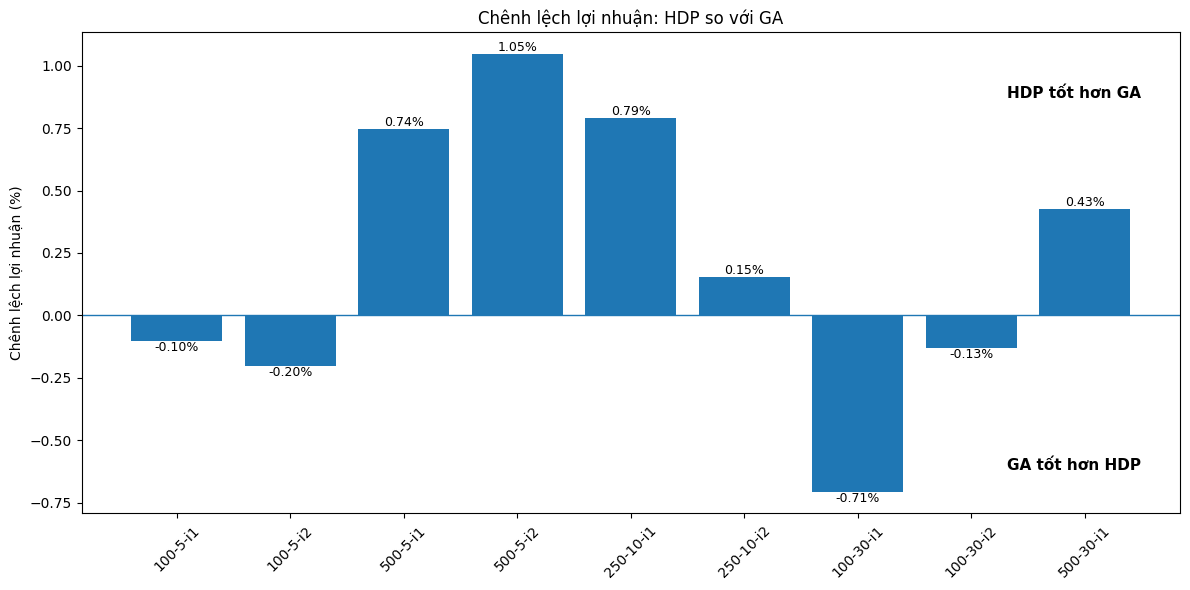

In [9]:
# Biểu đồ 1 — Chênh lệch lợi nhuận theo %
df = report_table.copy()

plt.figure(figsize=(12, 6))

bars = plt.bar(df["label"], df["profit_diff_percent"])
plt.axhline(0, linewidth=1)

plt.xticks(rotation=45)
plt.ylabel("Chênh lệch lợi nhuận (%)")
plt.title("Chênh lệch lợi nhuận: HDP so với GA")

y_max = df["profit_diff_percent"].max()
y_min = df["profit_diff_percent"].min()

plt.text(
    len(df) - 0.5,
    y_max * 0.85 if y_max != 0 else 0.5,
    "HDP tốt hơn GA",
    ha="right",
    va="center",
    fontsize=11,
    fontweight="bold"
)

plt.text(
    len(df) - 0.5,
    y_min * 0.85 if y_min != 0 else -0.5,
    "GA tốt hơn HDP",
    ha="right",
    va="center",
    fontsize=11,
    fontweight="bold"
)

for i, value in enumerate(df["profit_diff_percent"]):
    plt.text(
        i,
        value,
        f"{value:.2f}%",
        ha="center",
        va="bottom" if value >= 0 else "top",
        fontsize=9
    )

plt.tight_layout()
plt.savefig("profit_diff_percent_annotated.png", dpi=300, bbox_inches="tight")
plt.show()

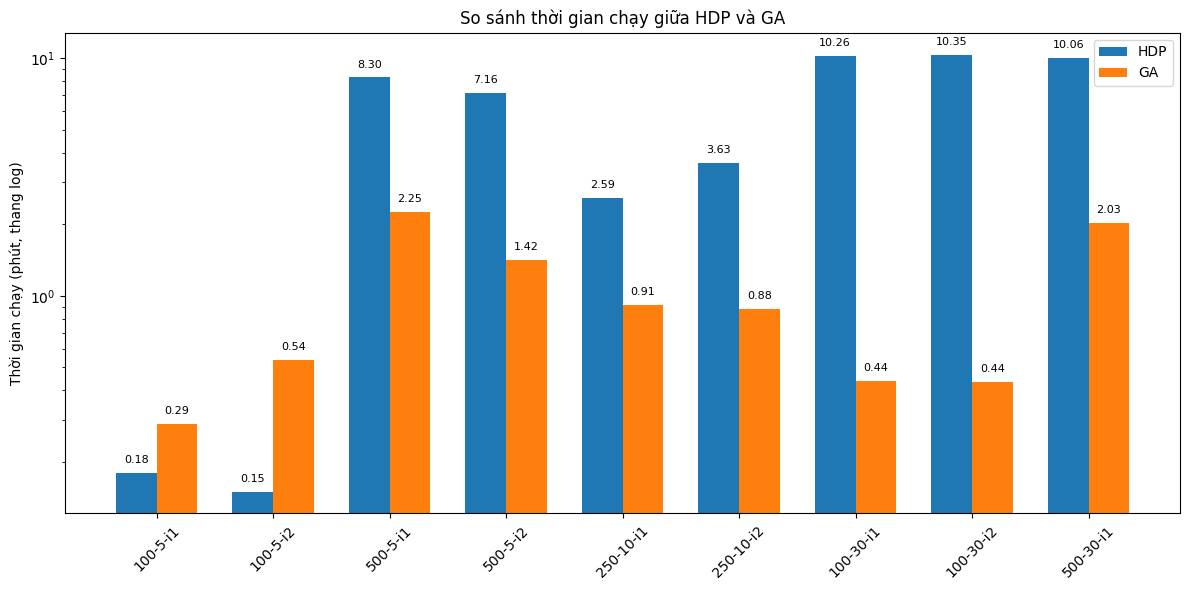

In [10]:
# Biểu đồ 2 - So sánh thời gian chạy
df = report_table.copy()

x = np.arange(len(df))
width = 0.35

plt.figure(figsize=(12, 6))

bars1 = plt.bar(x - width/2, df["time_min_hdp"], width, label="HDP")
bars2 = plt.bar(x + width/2, df["time_min_ga"], width, label="GA")

plt.yscale("log")
plt.xticks(x, df["label"], rotation=45)
plt.ylabel("Thời gian chạy (phút, thang log)")
plt.title("So sánh thời gian chạy giữa HDP và GA")
plt.legend()

for bar in bars1:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height * 1.08,
        f"{height:.2f}",
        ha="center",
        va="bottom",
        fontsize=8
    )

for bar in bars2:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height * 1.08,
        f"{height:.2f}",
        ha="center",
        va="bottom",
        fontsize=8
    )

plt.tight_layout()
plt.savefig("time_comparison_log_labeled.png", dpi=300, bbox_inches="tight")
plt.show()

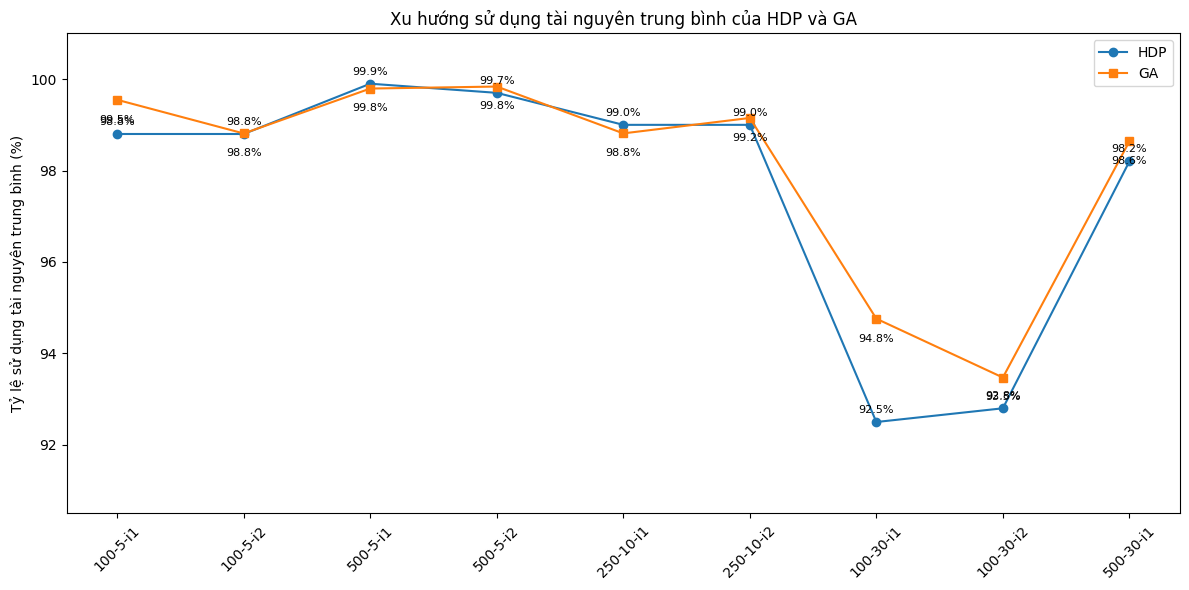

In [11]:
# Biểu đồ 3 - Xu hướng sử dụng tài nguyên trung bình
df = report_table.copy()

plt.figure(figsize=(12, 6))

plt.plot(df["label"], df["avg_usage_hdp_pct"], marker="o", label="HDP")
plt.plot(df["label"], df["avg_usage_ga_pct"], marker="s", label="GA")

plt.xticks(rotation=45)
plt.ylabel("Tỷ lệ sử dụng tài nguyên trung bình (%)")
plt.title("Xu hướng sử dụng tài nguyên trung bình của HDP và GA")

y_min = min(df["avg_usage_hdp_pct"].min(), df["avg_usage_ga_pct"].min()) - 2
plt.ylim(y_min, 101)

for i, row in df.iterrows():
    plt.text(
        i,
        row["avg_usage_hdp_pct"] + 0.2,
        f"{row['avg_usage_hdp_pct']:.1f}%",
        ha="center",
        fontsize=8
    )
    plt.text(
        i,
        row["avg_usage_ga_pct"] - 0.5,
        f"{row['avg_usage_ga_pct']:.1f}%",
        ha="center",
        fontsize=8
    )

plt.legend()
plt.tight_layout()
plt.savefig("resource_usage_line.png", dpi=300, bbox_inches="tight")
plt.show()